<a href="https://colab.research.google.com/github/lavenderoyugi/-Bicycle-Parking-Infrastructure-Analysis-in-the-Loire-Atlantique-Area-/blob/main/Lavender_Yutube.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 🚴 <mark>10 Smart Data Analysis Hacks — Loire-Atlantique Bicycle Parking</mark>
**Author:** Lavender Oyugi


In [4]:
# --- 1. Import Libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

In [5]:
# Set plotting style
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)


In [6]:
# =====================================================
# 2. Load Dataset
# =====================================================
link = "/content/244400644_stationnements_cyclables.csv"
df = pd.read_csv(link, sep=';')
df.head()

,geo_point_2d,Geo Shape,id_local,id_osm,code_com,coordonneesxy,capacite,capacite_cargo,type_accroche,mobilier,...,couverture,surveillance,lumiere,url_info,d_service,source,proprietaire,gestionnaire,date_maj,commentaires
0,"47.24014209999996, -2.2782823","{""coordinates"": [-2.2782823, 47.24014209999996...",40,n1655161104,44184,"[-2.2782823000000034,47.24014210000001]",4,NaN,ROUE,ARCEAU,...,Faux,Faux,Faux,NaN,NaN,© les contributeurs d’OpenStreetMap ; © CARENE,NaN,NaN,2022-09-19,NaN
1,"47.275722860270285, -2.205563401614654","{""coordinates"": [-2.205563401614654, 47.275722...",82,n1655161426,44184,"[-2.2055634016146564,47.27572286027034]",6,NaN,CADRE ET ROUE,ARCEAU,...,Faux,Faux,Faux,NaN,NaN,© les contributeurs d’OpenStreetMap ; © CARENE,NaN,NaN,2022-09-19,NaN
2,"47.285041587733524, -2.225726700976113","{""coordinates"": [-2.225726700976113, 47.285041...",540,NaN,44184,"[-2.225726700976119,47.28504158773357]",2,NaN,CADRE,ARCEAU,...,Faux,Faux,Faux,NaN,NaN,© CARENE,NaN,NaN,2022-09-19,NaN
3,"47.297832194912985, -2.193971151595806","{""coordinates"": [-2.193971151595806, 47.297832...",544,NaN,44184,"[-2.193971151595806,47.29783219491302]",3,NaN,ROUE,ARCEAU,...,Faux,Faux,Faux,NaN,NaN,© CARENE,NaN,NaN,2022-09-19,"stationnement amovible, mis à dispo par la lav..."
4,"47.28585974973144, -2.195954751533444","{""coordinates"": [-2.195954751533444, 47.285859...",545,NaN,44184,"[-2.195954751533448,47.28585974973149]",30,NaN,ROUE,RATELIER,...,Vrai,Faux,Faux,NaN,NaN,© CARENE,NaN,NaN,2022-09-19,salariés des chantiers navals


In [7]:
# =====================================================
# 3. Hack 1 — Quick Overview
# =====================================================
# Check data types, memory, and missing values
df.info()
print("\nMemory usage per column (KB):")
print(df.memory_usage(deep=True) / 1024)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 601 entries, 0 to 600
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   geo_point_2d    601 non-null    object 
 1   Geo Shape       601 non-null    object 
 2   id_local        601 non-null    int64  
 3   id_osm          439 non-null    object 
 4   code_com        601 non-null    int64  
 5   coordonneesxy   601 non-null    object 
 6   capacite        601 non-null    int64  
 7   capacite_cargo  1 non-null      float64
 8   type_accroche   601 non-null    object 
 9   mobilier        601 non-null    object 
 10  acces           601 non-null    object 
 11  gratuit         601 non-null    object 
 12  protection      601 non-null    object 
 13  couverture      589 non-null    object 
 14  surveillance    290 non-null    object 
 15  lumiere         290 non-null    object 
 16  url_info        10 non-null     object 
 17  d_service       11 non-null     flo

In [8]:
# =====================================================
# 4. Hack 2 — Optimize Data Types
# =====================================================
# Convert object columns to 'category' if few unique values
for col in df.select_dtypes(include='object').columns:
    if df[col].nunique() < len(df) / 2:
        df[col] = df[col].astype('category')

In [9]:
# Downcast numeric columns
for col in df.select_dtypes(include=['int64','float64']).columns:
    df[col] = pd.to_numeric(df[col], downcast='unsigned')

df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 601 entries, 0 to 600
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   geo_point_2d    601 non-null    object  
 1   Geo Shape       601 non-null    object  
 2   id_local        601 non-null    uint16  
 3   id_osm          439 non-null    object  
 4   code_com        601 non-null    uint16  
 5   coordonneesxy   601 non-null    object  
 6   capacite        601 non-null    uint8   
 7   capacite_cargo  1 non-null      float64 
 8   type_accroche   601 non-null    category
 9   mobilier        601 non-null    category
 10  acces           601 non-null    category
 11  gratuit         601 non-null    category
 12  protection      601 non-null    category
 13  couverture      589 non-null    category
 14  surveillance    290 non-null    category
 15  lumiere         290 non-null    category
 16  url_info        10 non-null     category
 17  d_service       

In [10]:
# =====================================================
# 5. Hack 3 — Quick Categorical Summary
# =====================================================
# Unique values per column
print(df.nunique())


geo_point_2d      600
Geo Shape         600
id_local          601
id_osm            437
code_com           10
coordonneesxy     600
capacite           25
capacite_cargo      1
type_accroche       3
mobilier            2
acces               2
gratuit             2
protection          3
couverture          2
surveillance        1
lumiere             2
url_info            2
d_service           4
source              5
proprietaire        4
gestionnaire       11
date_maj           11
commentaires       13
dtype: int64


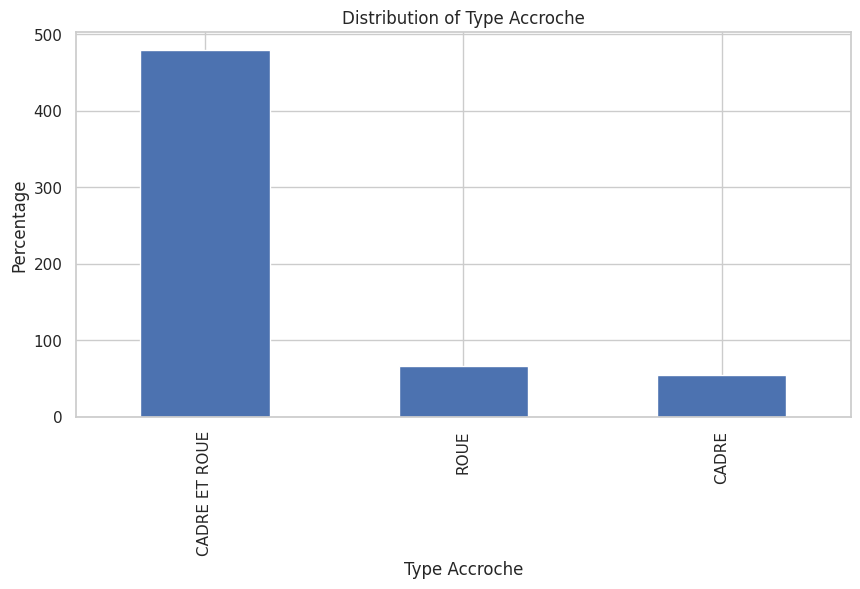

In [11]:
# Bar plot
df['type_accroche'].value_counts().plot(kind='bar', title='Distribution of Type Accroche')
plt.xlabel('Type Accroche')
plt.ylabel('Percentage')
plt.show()


In [12]:
# Distribution of bike parking types
df['type_accroche'].value_counts(normalize=True) * 100


,proportion
type_accroche,
CADRE ET ROUE,79.700499
ROUE,11.148087
CADRE,9.151414


In [13]:
# =====================================================
# 6. Hack 4 — Full Summary with describe()
# =====================================================
df.describe(include='all')pupupupupupup

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
geo_point_2d,601,600,"47.24797309999997, -2.3230367",2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Geo Shape,601,600,"{""coordinates"": [-2.3230367, 47.24797309999997...",2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
id_local,601.0,NaN,NaN,NaN,340.860233,194.827275,1.0,173.0,341.0,508.0,675.0
id_osm,439,437,w149948952,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
code_com,601.0,NaN,NaN,NaN,44164.159734,38.711296,44013.0,44132.0,44184.0,44184.0,44210.0
coordonneesxy,601,600,"[-2.323036700000004,47.247973100000024]",2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
capacite,601.0,NaN,NaN,NaN,7.628952,5.392627,0.0,4.0,6.0,10.0,48.0
capacite_cargo,1.0,NaN,NaN,NaN,2.0,NaN,2.0,2.0,2.0,2.0,2.0
type_accroche,601,3,CADRE ET ROUE,479,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mobilier,601,2,ARCEAU,585,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
# =====================================================
# 7. Hack 5 — Handle Missing Data
# =====================================================
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns

df[num_cols] = df[num_cols].fillna(df[num_cols].median())
df[cat_cols] = df[cat_cols].apply(lambda x: x.fillna(x.mode()[0]))
print("\nRemaining missing values:", df.isnull().sum().sum())


Remaining missing values: 0


In [15]:
# =====================================================
# 8. Hack 6 — Transform Columns Quickly
# =====================================================
df['parking_size'] = df['capacite'].apply(lambda x: 'Large' if x > 10 else 'Small/Medium')
df[['capacite','parking_size']].head()


,capacite,parking_size
0,4,Small/Medium
1,6,Small/Medium
2,2,Small/Medium
3,3,Small/Medium
4,30,Large


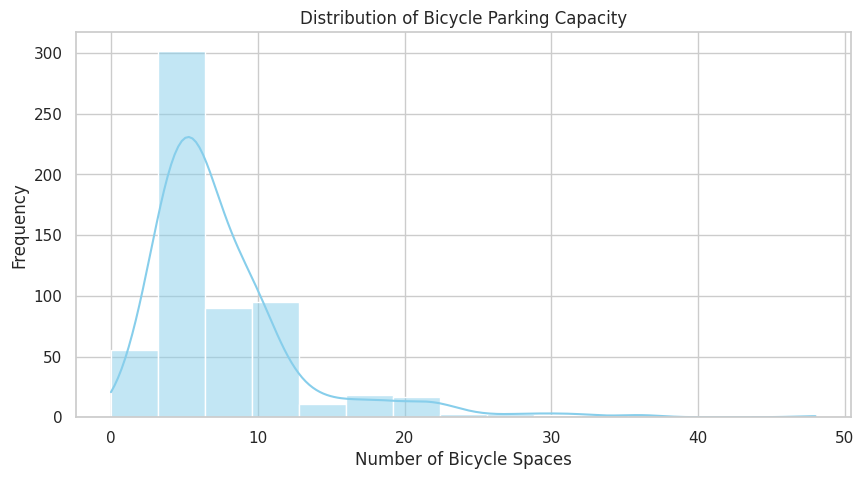

In [16]:
# =====================================================
# 9. Hack 7 — Visualization
# =====================================================
sns.histplot(df['capacite'], bins=15, kde=True, color='skyblue')
plt.title('Distribution of Bicycle Parking Capacity')
plt.xlabel('Number of Bicycle Spaces')
plt.ylabel('Frequency')
plt.show()


In [17]:
# =====================================================
# 10. Hack 8 — Fast Filtering with query()
# =====================================================
large_parks = df.query("capacite > 15")
print("Number of large-capacity locations:", len(large_parks))
large_parks.head()

Number of large-capacity locations: 48


,geo_point_2d,Geo Shape,id_local,id_osm,code_com,coordonneesxy,capacite,capacite_cargo,type_accroche,mobilier,...,surveillance,lumiere,url_info,d_service,source,proprietaire,gestionnaire,date_maj,commentaires,parking_size
4,"47.28585974973144, -2.195954751533444","{""coordinates"": [-2.195954751533444, 47.285859...",545,n5834058088,44184,"[-2.195954751533448,47.28585974973149]",30,2.0,ROUE,RATELIER,...,Faux,Faux,https://www.velyceo.com/abris-velos,2023.0,© CARENE,CARENE,Ville de Saint-Nazaire,2022-09-19,salariés des chantiers navals,Large
21,"47.249721299999955, -2.3279398","{""coordinates"": [-2.3279398, 47.24972129999995...",294,n7783537832,44132,"[-2.3279398000000024,47.2497213]",18,2.0,CADRE ET ROUE,ARCEAU,...,Faux,Faux,https://www.velyceo.com/abris-velos,2023.0,© les contributeurs d’OpenStreetMap ; © CARENE,CARENE,Ville de Saint-Nazaire,2022-09-19,Abonnement annuel 12 € ; Accès avec le pass mo...,Large
22,"47.24940219999995, -2.3282756","{""coordinates"": [-2.3282756, 47.24940219999995...",299,n7783537831,44132,"[-2.3282756000000027,47.2494022]",30,2.0,CADRE ET ROUE,ARCEAU,...,Faux,Faux,https://www.velyceo.com/abris-velos,2023.0,© les contributeurs d’OpenStreetMap ; © CARENE,CARENE,Ville de Saint-Nazaire,2022-09-19,Abonnement annuel 12 € ; Accès avec le pass mo...,Large
45,"47.25874784038472, -2.341465161981531","{""coordinates"": [-2.341465161981531, 47.258747...",573,n5834058088,44132,"[-2.341465161981539,47.25874784038478]",24,2.0,CADRE ET ROUE,ARCEAU,...,Faux,Faux,https://www.velyceo.com/abris-velos,2023.0,© CARENE,CARENE,Ville de Saint-Nazaire,2022-09-19,Abonnement annuel 12 € ; Accès avec le pass mo...,Large
46,"47.2640206760803, -2.344025366923652","{""coordinates"": [-2.344025366923652, 47.264020...",578,n5834058088,44132,"[-2.3440253669236597,47.26402067608034]",48,2.0,CADRE ET ROUE,ARCEAU,...,Faux,Faux,https://www.velyceo.com/abris-velos,2023.0,© CARENE,CARENE,Ville de Saint-Nazaire,2022-09-19,Abonnement annuel 12 € ; Accès avec le pass mo...,Large


In [18]:
# =====================================================
# 11. Hack 9 — Compare Processing Time
# =====================================================
start = time.time()
df[df['capacite'] > 10]
normal_time = time.time() - start

start = time.time()
df.query("capacite > 10")
query_time = time.time() - start

print(f"Normal filter time: {normal_time:.6f} sec")
print(f"Query filter time: {query_time:.6f} sec")


Normal filter time: 0.002121 sec
Query filter time: 0.006944 sec


In [19]:
# =====================================================
# 12. Hack 10 — Add Geographic Insight
# =====================================================
df[['latitude','longitude']] = df['geo_point_2d'].str.split(',', expand=True)
df['latitude'] = df['latitude'].astype(float)
df['longitude'] = df['longitude'].astype(float)

avg_capacity = df.groupby('code_com')['capacite'].mean().sort_values(ascending=False)
avg_capacity.head(5)


,capacite
code_com,
44132,8.706422
44184,7.981383
44176,6.857143
44103,6.333333
44210,6.333333


In [20]:
# =====================================================
# 13. Wrap-Up — Summary
# =====================================================
print("""
==================================
✨ SUMMARY OF WHAT WE LEARNED
==================================
1️⃣ Check memory and optimize data types
2️⃣ Summarize numeric and categorical data
3️⃣ Handle missing values efficiently
4️⃣ Transform columns quickly
5️⃣ Visualize data for patterns
6️⃣ Filter efficiently with query()
7️⃣ Measure processing speed
8️⃣ Add geographic insights
""")


✨ SUMMARY OF WHAT WE LEARNED
1️⃣ Check memory and optimize data types
2️⃣ Summarize numeric and categorical data
3️⃣ Handle missing values efficiently
4️⃣ Transform columns quickly
5️⃣ Visualize data for patterns
6️⃣ Filter efficiently with query()
7️⃣ Measure processing speed
8️⃣ Add geographic insights

